<a href="https://colab.research.google.com/github/ganesh10-code/DL_Lab/blob/main/DL_Frameworks.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Week-1
**1. Build a Simple Neural Network with PyTorch**

In [ ]:
#building simple neural network with Pytorch
import torch
import torch.nn as nn
import torch.optim as optim

#Creating random data
X=torch.randn(100,3)
Y=torch.randn(100,1)

#defining model
class SimpleNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.linear=nn.Linear(3,1)
    def forward(self,X):
        return self.linear(X)

model=SimpleNN()
loss_fn=nn.MSELoss()
optimizer=optim.Adam(model.parameters(),lr=0.01)

#Training
for epoch in range(100):
    optimizer.zero_grad()
    y_pred=model(X)
    loss=loss_fn(y_pred,Y)
    loss.backward()
    optimizer.step()
    if(epoch%10==0):
        print(f'epoch:{epoch}, loss: {loss}')
print(f'final loss:{loss}')


epoch:0, loss: 1.0738766193389893
epoch:10, loss: 0.9509066939353943
epoch:20, loss: 0.8914304971694946
epoch:30, loss: 0.8613380193710327
epoch:40, loss: 0.8434795141220093
epoch:50, loss: 0.8362269401550293
epoch:60, loss: 0.8340688943862915
epoch:70, loss: 0.8337029218673706
epoch:80, loss: 0.8337094783782959
epoch:90, loss: 0.8337184190750122
final loss:0.8336991667747498


**2. Simple Neural Network with TensorFlow**

In [ ]:
#Simple Neural Network using TensorFlow
import tensorflow as tf

x=tf.random.normal((100,3))
y=tf.random.normal((100,1))

model= tf.keras.Sequential([tf.keras.layers.Dense(1,input_shape=(3,))])
model.compile(optimizer='adam',loss='MSE')
model.fit(x,y,epochs=100,verbose=0)
print("Final Loss: ",model.evaluate(x,y))

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - loss: 0.9993
Final Loss:  0.9805908203125


**3. Simple Neural Network with Using Keras (via tf.keras)**

In [ ]:
#Simple Neural Network using Keras
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

x= tf.random.normal((100,3))
y= tf.random.normal((100,1))

model = keras.Sequential([layers.Dense(1,input_shape=(3,))])

model.compile(optimizer='adam',loss='mse')
model.fit(x,y,epochs=100,verbose=0)
print("final loss: ",model.evaluate(x,y))

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - loss: 1.8359
final loss:  1.8999983072280884


**4. IMPLEMENT A SIMPLE PERCEPTRON (Coding a Neuron) and explain the meaning of feed-forward, step, and sigmoid functions**

In [ ]:
#simple perceptron for AND logic
import numpy as np
class Perceptron:
    def __init__(self,weights,bias):
        self.weights=weights
        self.bias=bias
    def step(self,x):
        return 1 if(x>=0) else 0
    def predict(self,input):
        total=np.dot(self.weights,input)+self.bias
        return self.step(total)
#AND Logic
weights=[1,1]
bias=-1.5
and_logic=Perceptron(weights,bias)
X=[[0,0],[0,1],[1,0],[1,1]]
print("AND Logic")
for x in X:
    print(x,"->",and_logic.predict(x))

AND Logic
[0, 0] -> 0
[0, 1] -> 0
[1, 0] -> 0
[1, 1] -> 1


# Week 2
**1. Implement AND and OR logic operations using a single perceptron, and verify the correctness of the output using appropriate truth tables. (linear Data)**

In [ ]:
# AND , OR Logic using simple perceptron
import numpy as np
class Perceptron:
    def __init__(self,weights,bias):
        self.weights=weights
        self.bias=bias
    def step(self,x):
        return 1 if(x>=0) else 0
    def predict(self,input):
        total=np.dot(self.weights,input)+self.bias
        return self.step(total)

X=[[0,0],[0,1],[1,0],[1,1]]
#AND Logic
and_weights=[1,1]
and_bias=-1.5
and_logic=Perceptron(and_weights,and_bias)
print("AND Logic")
for x in X:
    print(x,"->",and_logic.predict(x))

#OR Logic
or_weights=[1,1]
or_bias=-0.5
or_logic=Perceptron(or_weights,or_bias)
print("OR Logic")
for x in X:
    print(x,"->",or_logic.predict(x
                                 ))

AND Logic
[0, 0] -> 0
[0, 1] -> 0
[1, 0] -> 0
[1, 1] -> 1
OR Logic
[0, 0] -> 0
[0, 1] -> 1
[1, 0] -> 1
[1, 1] -> 1


**2. Examine the feasibility of implementing the XOR and XNOR (¬XOR) operations (Non linear data) using a single perceptron. If not possible, clearly explain the reason based on the concept of linear separability.**

In [ ]:
#Implementing XOR and XNOR using single perceptron
import numpy as np
from sklearn.linear_model import Perceptron

X=np.array([[0,0],[0,1],[1,0],[1,1]])
xor_y=[0,1,1,0]
xnor_y=[1,0,0,1]

#XOR
xor_model=Perceptron(max_iter=1000)
xor_model.fit(X,xor_y)
print("---XOR---")
print("Actual: ",xor_y)
print("prediction: ",xor_model.predict(X))

#XNOR
xnor_model=Perceptron(max_iter=1000)
xnor_model.fit(X,xnor_y)
print("---XNOR---")
print("Actual: ",xnor_y)
print("prediction: ",xnor_model.predict(X))

---XOR---
Actual:  [0, 1, 1, 0]
prediction:  [0 0 0 0]
---XNOR---
Actual:  [1, 0, 0, 1]
prediction:  [0 0 0 0]


**3. Implement the XOR and (¬XOR) logic operation using a multi-perceptron network, and analyze how multiple perceptrons overcome the limitations of a single perceptron.**

In [ ]:
#XOR logic using MLP
import numpy as np
def perceptron(x1,x2,w1,w2,b):
    return step(x1*w1+x2*w2+b)
def step(x):
    return 1 if x>=0 else 0
def predict(x):
        h1=perceptron(x[0],x[1],1,1,-0.5)   #OR logic
        h2=perceptron(x[0],x[1],-1,-1,1.5)   #NAND logic
        output=perceptron(h1,h2,1,1,-1.5)   #AND logic
        return output

X=np.array([[0,0],[0,1],[1,0],[1,1]])
print("---XOR---")
for x in X:
    print(x,"->",predict(x))

---XOR---
[0 0] -> 0
[0 1] -> 1
[1 0] -> 1
[1 1] -> 0


**4. Demonstrate that the thresholding logic used by perceptron is very harsh.**

In [ ]:
import numpy as np
def step(x):
    return 1 if x>=0 else 0
def perceptron(input,weight,bias):
    return step(input*weight+bias)

weight=1
bias=0
#inputs
inputs=[-0.0001,-0.01,-0.1,0,0.1,0.001]
for x in inputs:
    print(x,"->",perceptron(x,weight,bias))

-0.0001 -> 0
-0.01 -> 0
-0.1 -> 0
0 -> 1
0.1 -> 1
0.001 -> 1


**5. Implement the Perceptron Learning Algorithm and study the effect of weight updates on convergence for a binary decision problem such as determining whether a user would like to watch a movie.
Note: Consider a small dataset(design your own excel csv sheet) of movie records with Boolean or real-valued features, for example:
 f1​: Is actor Matt Damon present
 f2​: Is the genre Thriller
 f3​: Is the director Christopher Nolan
 f4: IMDb rating (scaled between 0 and 1)
The output label represents like (1) or dislike (0). Train the perceptron model using these features and observe how weight updates influence convergence and classification performance.
Test with a sample record to show whether a perceptron properly classifies it or not.
i) Check with MP Perceptron  (without weights and bias)
ii) Check with Perceptron (with weights)
iii) Check with Perceptron (with weights and bias)**

In [ ]:
import pandas as pd
import numpy as np

movie = {
    "Matt_Damon": [1,1,0,0,0,1,0,1],
    "Thriller":   [1,0,1,0,1,0,0,1],
    "Nolan":      [1,0,1,0,0,1,1,0],
    "IMDb":       [0.9,0.7,0.8,0.4,0.5,0.85,0.6,0.75],
    "Like":       [1,1,1,0,0,1,0,1]
}
df=pd.DataFrame(movie)
df.to_csv("movies.csv",index=False)

data=pd.read_csv('/kaggle/working/movies.csv')
X=data.iloc[:,0:4].values
y=data.iloc[:,4].values

# i.Mp Neuron
def mp_neuron(x):
    threshold=1
    return 1 if sum(x)>threshold else 0

print("---MP Neuron---")
for i in range(len(X)):
    print(X[i],"\tpredicted: ",mp_neuron(X[i]),"\tActual: ",y[i])

# ii.perceptron with weights
weights=np.zeros(4)
lr=0.1
for epoch in range(10):
    for i in range(len(X)):
        z=np.dot(X[i],weights)
        pred= 1 if z>=0 else 0
        error=y[i]-pred
        weights+=lr*error*X[i]
print("\n---Perceptron with weights---")
print("Weights after training: ",weights)
for i in range(len(X)):
    z=np.dot(X[i],weights)
    pred= 1 if z>=0 else 0
    print(X[i],"\tpredicted:",pred,"\tActual:",y[i])

# iii. perceptron with weights and bias
weights=np.zeros(4)
bias=0
lr=0.1
for epoch in range(10):
    for i in range(len(X)):
        z=np.dot(X[i],weights)+bias
        pred= 1 if z>=0 else 0
        error=y[i]-pred
        weights+=lr*error*X[i]
        bias+=lr*error
print("\n---Perceptron with weights and bias---")
print("Weights and bias after training:\n weights:",weights,"\tbias:",bias)
for i in range(len(X)):
    z=np.dot(X[i],weights)+bias
    pred= 1 if z>=0 else 0
    print(X[i],"\tpredicted:",pred,"\tActual:",y[i])

---MP Neuron---
[1.  1.  1.  0.9] 	predicted:  1 	Actual:  1
[1.  0.  0.  0.7] 	predicted:  1 	Actual:  1
[0.  1.  1.  0.8] 	predicted:  1 	Actual:  1
[0.  0.  0.  0.4] 	predicted:  0 	Actual:  0
[0.  1.  0.  0.5] 	predicted:  1 	Actual:  0
[1.   0.   1.   0.85] 	predicted:  1 	Actual:  1
[0.  0.  1.  0.6] 	predicted:  1 	Actual:  0
[1.   1.   0.   0.75] 	predicted:  1 	Actual:  1

---Perceptron with weights---
Weights after training:  [ 0.3    0.     0.1   -0.245]
[1.  1.  1.  0.9] 	predicted: 1 	Actual: 1
[1.  0.  0.  0.7] 	predicted: 1 	Actual: 1
[0.  1.  1.  0.8] 	predicted: 0 	Actual: 1
[0.  0.  0.  0.4] 	predicted: 0 	Actual: 0
[0.  1.  0.  0.5] 	predicted: 0 	Actual: 0
[1.   0.   1.   0.85] 	predicted: 1 	Actual: 1
[0.  0.  1.  0.6] 	predicted: 0 	Actual: 0
[1.   1.   0.   0.75] 	predicted: 1 	Actual: 1

---Perceptron with weights and bias---
Weights and bias after training:
 weights: [0.4  0.1  0.1  0.07] 	bias: -0.20000000000000004
[1.  1.  1.  0.9] 	predicted: 1 	Actual: 1
[1


**6. Demonstrate the Representation Power of a Network of Perceptrons- How many Boolean functions can be designed using two binary inputs?- For each Boolean function, determine whether it is linearly separable.- Implement a single perceptron model and test whether it can correctly learn each Boolean function. (Mention how many it can't learn and why)- Extend the program to estimate or analyze how the number of non-linearly separable Boolean functions increases as the number of inputs n grows.**


In [ ]:
import numpy as np
from itertools import product

X=np.array([[0,0],[0,1],[1,0],[1,1]])
functions=list(product([0,1],repeat=4))

epochs=20
lr=0.1

def train_perceptron(x,y):
    weights=np.zeros(2)
    bias=0
    for epoch in range(epochs):
        error_count=0
        for i in range(len(x)):
            z=np.dot(x[i],weights)+bias
            pred= 1 if z>=0 else 0
            error=y[i]-pred
            weights+=lr*error*x[i]
            bias+=lr*error
            if(error!=0):
                error_count+=1
        if error_count==0:
            return True
    return False

learned=0
not_learned=0
for i,f in enumerate(functions):
    y=np.array(f)
    result=train_perceptron(X,y)
    if result:
        learned+=1
        status="Linearly Seperable"
    else:
        not_learned+=1
        status="Not Linearly Separable"
    print("Function:",i,":",f,"->",status)

print("Learned: ",learned,"\t Not Learned: ",not_learned)


Function: 0 : (0, 0, 0, 0) -> Linearly Seperable
Function: 1 : (0, 0, 0, 1) -> Linearly Seperable
Function: 2 : (0, 0, 1, 0) -> Linearly Seperable
Function: 3 : (0, 0, 1, 1) -> Linearly Seperable
Function: 4 : (0, 1, 0, 0) -> Linearly Seperable
Function: 5 : (0, 1, 0, 1) -> Linearly Seperable
Function: 6 : (0, 1, 1, 0) -> Not Linearly Separable
Function: 7 : (0, 1, 1, 1) -> Linearly Seperable
Function: 8 : (1, 0, 0, 0) -> Linearly Seperable
Function: 9 : (1, 0, 0, 1) -> Not Linearly Separable
Function: 10 : (1, 0, 1, 0) -> Linearly Seperable
Function: 11 : (1, 0, 1, 1) -> Linearly Seperable
Function: 12 : (1, 1, 0, 0) -> Linearly Seperable
Function: 13 : (1, 1, 0, 1) -> Linearly Seperable
Function: 14 : (1, 1, 1, 0) -> Linearly Seperable
Function: 15 : (1, 1, 1, 1) -> Linearly Seperable
Learned:  14 	 Not Learned:  2



**7. Design and implement a Multi-Layer Perceptron (MLP) architecture capable of realizing all basic Boolean functions  Hint: By finding the weights w1,w2,w3,w4 such that the truth table of any boolean function can be represented by this network. Also Each perceptron in the middle layer fires only for a specific input (and no two perceptrons fire for the same input)**


In [ ]:
import numpy as np
from itertools import product

# Step activation function
def step(z):
    return 1 if z >= 0 else 0

# Hidden layer perceptrons
def hidden_layer(x1, x2):
    h1 = step(-x1 - x2 + 0.5)      # fires for (0,0)
    h2 = step(-x1 + x2 - 0.5)      # fires for (0,1)
    h3 = step(x1 - x2 - 0.5)       # fires for (1,0)
    h4 = step(x1 + x2 - 1.5)       # fires for (1,1)
    return np.array([h1,h2,h3,h4])

# MLP model
def mlp(x1,x2,weights):
    hidden = hidden_layer(x1,x2)
    z = np.dot(hidden,weights)
    return step(z)

inputs = [(0,0),(0,1),(1,0),(1,1)]

# Generating all Boolean functions
functions = list(product([0,1], repeat=4))

print("Testing Boolean Functions\n")

for f in functions:
    weights = np.array(f)
    print("Function:",f)
    for i,(x1,x2) in enumerate(inputs):
        pred = mlp(x1,x2,weights)
        print((x1,x2),"->",pred)
    print()

Testing Boolean Functions

Function: (0, 0, 0, 0)
(0, 0) -> 1
(0, 1) -> 1
(1, 0) -> 1
(1, 1) -> 1

Function: (0, 0, 0, 1)
(0, 0) -> 1
(0, 1) -> 1
(1, 0) -> 1
(1, 1) -> 1

Function: (0, 0, 1, 0)
(0, 0) -> 1
(0, 1) -> 1
(1, 0) -> 1
(1, 1) -> 1

Function: (0, 0, 1, 1)
(0, 0) -> 1
(0, 1) -> 1
(1, 0) -> 1
(1, 1) -> 1

Function: (0, 1, 0, 0)
(0, 0) -> 1
(0, 1) -> 1
(1, 0) -> 1
(1, 1) -> 1

Function: (0, 1, 0, 1)
(0, 0) -> 1
(0, 1) -> 1
(1, 0) -> 1
(1, 1) -> 1

Function: (0, 1, 1, 0)
(0, 0) -> 1
(0, 1) -> 1
(1, 0) -> 1
(1, 1) -> 1

Function: (0, 1, 1, 1)
(0, 0) -> 1
(0, 1) -> 1
(1, 0) -> 1
(1, 1) -> 1

Function: (1, 0, 0, 0)
(0, 0) -> 1
(0, 1) -> 1
(1, 0) -> 1
(1, 1) -> 1

Function: (1, 0, 0, 1)
(0, 0) -> 1
(0, 1) -> 1
(1, 0) -> 1
(1, 1) -> 1

Function: (1, 0, 1, 0)
(0, 0) -> 1
(0, 1) -> 1
(1, 0) -> 1
(1, 1) -> 1

Function: (1, 0, 1, 1)
(0, 0) -> 1
(0, 1) -> 1
(1, 0) -> 1
(1, 1) -> 1

Function: (1, 1, 0, 0)
(0, 0) -> 1
(0, 1) -> 1
(1, 0) -> 1
(1, 1) -> 1

Function: (1, 1, 0, 1)
(0, 0) -> 1
(0


**8. How many Boolean functions can be designed using three binary inputs?Find respective weights w1 to w8) and demonstrate for all the possible boolean functions for three inputs. Summary: Universal Approximation theorem: A MLP with a single hidden layer can represent any boolean function.**

In [ ]:
import numpy as np
from itertools import product

def step(z):
    return 1 if z >= 0 else 0

def hidden_layer(x1,x2,x3):
    h1 = step(-x1 -x2 -x3 +0.5)
    h2 = step(-x1 -x2 +x3 -0.5)
    h3 = step(-x1 +x2 -x3 -0.5)
    h4 = step(-x1 +x2 +x3 -1.5)
    h5 = step(x1 -x2 -x3 -0.5)
    h6 = step(x1 -x2 +x3 -1.5)
    h7 = step(x1 +x2 -x3 -1.5)
    h8 = step(x1 +x2 +x3 -2.5)
    return np.array([h1,h2,h3,h4,h5,h6,h7,h8])

def mlp(x1,x2,x3,weights):
    hidden = hidden_layer(x1,x2,x3)
    z = np.dot(hidden,weights)
    return step(z)

inputs = list(product([0,1],[0,1],[0,1]))

functions = list(product([0,1],repeat=8))

print("Total Boolean Functions:",len(functions))

for f in functions[:6]:
    weights=np.array(f)
    print("\nFunction:",f)
    for i,(x1,x2,x3) in enumerate(inputs):
        pred = mlp(x1,x2,x3,weights)
        print((x1,x2,x3),"->",pred)

Total Boolean Functions: 256

Function: (0, 0, 0, 0, 0, 0, 0, 0)
(0, 0, 0) -> 1
(0, 0, 1) -> 1
(0, 1, 0) -> 1
(0, 1, 1) -> 1
(1, 0, 0) -> 1
(1, 0, 1) -> 1
(1, 1, 0) -> 1
(1, 1, 1) -> 1

Function: (0, 0, 0, 0, 0, 0, 0, 1)
(0, 0, 0) -> 1
(0, 0, 1) -> 1
(0, 1, 0) -> 1
(0, 1, 1) -> 1
(1, 0, 0) -> 1
(1, 0, 1) -> 1
(1, 1, 0) -> 1
(1, 1, 1) -> 1

Function: (0, 0, 0, 0, 0, 0, 1, 0)
(0, 0, 0) -> 1
(0, 0, 1) -> 1
(0, 1, 0) -> 1
(0, 1, 1) -> 1
(1, 0, 0) -> 1
(1, 0, 1) -> 1
(1, 1, 0) -> 1
(1, 1, 1) -> 1

Function: (0, 0, 0, 0, 0, 0, 1, 1)
(0, 0, 0) -> 1
(0, 0, 1) -> 1
(0, 1, 0) -> 1
(0, 1, 1) -> 1
(1, 0, 0) -> 1
(1, 0, 1) -> 1
(1, 1, 0) -> 1
(1, 1, 1) -> 1

Function: (0, 0, 0, 0, 0, 1, 0, 0)
(0, 0, 0) -> 1
(0, 0, 1) -> 1
(0, 1, 0) -> 1
(0, 1, 1) -> 1
(1, 0, 0) -> 1
(1, 0, 1) -> 1
(1, 1, 0) -> 1
(1, 1, 1) -> 1

Function: (0, 0, 0, 0, 0, 1, 0, 1)
(0, 0, 0) -> 1
(0, 0, 1) -> 1
(0, 1, 0) -> 1
(0, 1, 1) -> 1
(1, 0, 0) -> 1
(1, 0, 1) -> 1
(1, 1, 0) -> 1
(1, 1, 1) -> 1


# Week 3
**9. Implement an MLP by varying bias, weights, and learning rate, and record observations for different learning rate values. Plot a graph showing the relationship between loss (error) and learning rate.**

Learning rate:0.01  loss:0.251
Learning rate:0.05  loss:0.251
Learning rate:0.1  loss:0.251
Learning rate:0.25  loss:0.260
Learning rate:0.5  loss:0.253
Learning rate:0.75  loss:0.251
Learning rate:1  loss:0.250
Learning rate:1.5  loss:0.250
Learning rate:2  loss:0.250
Learning rate:3  loss:0.250


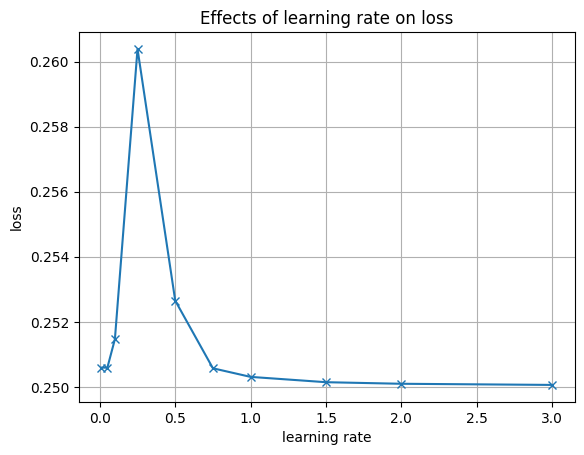

In [ ]:
#Implement MLP and relation b/w loss and learning rate
import matplotlib.pyplot as plt
import numpy as np

X=np.array([[0,0],[0,1],[1,0],[1,1]])
Y=np.array([[1],[0],[0],[1]])

learning_rates=[0.01,0.05,0.1,0.25,0.5,0.75,1,1.5,2,3]
epoches=1000
losses=[]
def sigmoid(x):
    return  1/(1+ np.exp(-x))

def sigmoid_derivative(x):
    return x*(1-x)

for lr in learning_rates:
    np.random.seed(42)
    W1=np.random.rand(2,2)
    B1=np.random.rand(1,2)
    W2=np.random.rand(2,1)
    B2=np.random.rand(1,1)
    for epoch in range(epoches):
        hidden_input=np.dot(X,W1)+B1
        hidden_output=sigmoid(hidden_input)
        final_input=np.dot(hidden_input,W2)+B2
        y_pred=sigmoid(final_input)
        error=Y-y_pred
        loss=np.mean(error**2)
        #backpropogation
        d_output = error * sigmoid_derivative(y_pred)
        d_hidden = d_output.dot(W2.T) * sigmoid_derivative(hidden_output)
        #updating weights and bias
        W2 += hidden_output.T.dot(d_output) * lr
        B2 += np.sum(d_output, axis=0, keepdims=True) * lr
        W1 += X.T.dot(d_hidden) * lr
        B1 += np.sum(d_hidden, axis=0, keepdims=True) * lr

    losses.append(loss)
    print(f"Learning rate:{lr}  loss:{loss:.3f}")

plt.figure()
plt.xlabel("learning rate")
plt.ylabel("loss")
plt.plot(learning_rates,losses,marker='x')
plt.title("Effects of learning rate on loss")
plt.grid(True)
plt.show()

**10. Implement an MLP using the Gradient Descent algorithm, and analyze the convergence behavior and performance of the network.**

In [ ]:
import numpy as np

# XOR data
X = np.array([[0,0],[0,1],[1,0],[1,1]])
y = np.array([[0],[1],[1],[0]])

np.random.seed(42)
W1 = np.random.randn(2,2)
b1 = np.zeros((1,2))
W2 = np.random.randn(2,1)
b2 = np.zeros((1,1))
lr = 0.1
epochs = 30000

def sigmoid(x):
    return 1/(1+np.exp(-x))

def sigmoid_derivative(x):
    return x*(1-x)

for epoch in range(epochs):
    # forward propagation
    z1 = np.dot(X,W1) + b1
    a1 = sigmoid(z1)
    z2 = np.dot(a1,W2) + b2
    a2 = sigmoid(z2)
    # loss [MSE]
    loss = np.mean((y-a2)**2)
    # backpropagation
    d2 = (a2-y)*sigmoid_derivative(a2)
    dW2 = np.dot(a1.T,d2)
    d1 = np.dot(d2,W2.T)*sigmoid_derivative(a1)
    dW1 = np.dot(X.T,d1)
    # gradient descent update
    W2 -= lr*dW2
    b2 -= lr*np.sum(d2)
    W1 -= lr*dW1
    b1 -= lr*np.sum(d1)
    if epoch%1000==0:
        print("Epoch:",epoch,"Loss:",loss)

print("\nPredictions:")
print(np.round(a2))

Epoch: 0 Loss: 0.2558299419444368
Epoch: 1000 Loss: 0.24940653777438804
Epoch: 2000 Loss: 0.24469441048439716
Epoch: 3000 Loss: 0.21386115182819956
Epoch: 4000 Loss: 0.18635179489489648
Epoch: 5000 Loss: 0.17705141239016678
Epoch: 6000 Loss: 0.17290686964187812
Epoch: 7000 Loss: 0.1701939129613439
Epoch: 8000 Loss: 0.1672026046811439
Epoch: 9000 Loss: 0.15969238614204395
Epoch: 10000 Loss: 0.14354443938171474
Epoch: 11000 Loss: 0.13643433249150042
Epoch: 12000 Loss: 0.13306726221350307
Epoch: 13000 Loss: 0.1311591279247091
Epoch: 14000 Loss: 0.12995135367208854
Epoch: 15000 Loss: 0.12912525447153567
Epoch: 16000 Loss: 0.12852751984782756
Epoch: 17000 Loss: 0.12807634626684408
Epoch: 18000 Loss: 0.12772445159720772
Epoch: 19000 Loss: 0.1274427360626339
Epoch: 20000 Loss: 0.12721236617091858
Epoch: 21000 Loss: 0.12702064156638296
Epoch: 22000 Loss: 0.12685870043049138
Epoch: 23000 Loss: 0.126720178846783
Epoch: 24000 Loss: 0.12660039305698925
Epoch: 25000 Loss: 0.1264958219841143
Epoch: 

**11. Implement a Perceptron on IRIS Dataset what are your observations with respect to learning rate using Perceptron class in sklearn. (explore all the parameters of Perceptron class).**

In [ ]:
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.linear_model import Perceptron
from sklearn.metrics import accuracy_score

# loading dataset
iris = load_iris()
X = iris.data
y = iris.target

X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.3)

model = Perceptron(max_iter=1000, eta0=0.01)
model.fit(X_train,y_train)
pred = model.predict(X_test)

print("Accuracy:",accuracy_score(y_test,pred))

Accuracy: 0.7111111111111111


**12. Implement MLP on any dataset and explore what particular parameters works for it such as learning rate, iterations etc**

In [ ]:
from sklearn.neural_network import MLPClassifier
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

iris = load_iris()
X = iris.data
y = iris.target

X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.3)

model = MLPClassifier(
        hidden_layer_sizes=(10,),
        learning_rate_init=0.01,
        max_iter=1000)

model.fit(X_train,y_train)
pred = model.predict(X_test)
print("Accuracy:",accuracy_score(y_test,pred))

Accuracy: 1.0


**13. Implement MLP with appropriate number of hidden layers and perceptrons to learn hand written digit dataset(MNIST).**

In [ ]:
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score

# loading MNIST dataset
mnist = fetch_openml('mnist_784')

X = mnist.data
y = mnist.target

# normalizing values
X = X/255.0

X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2)

# MLP model
model = MLPClassifier(
        hidden_layer_sizes=(128,64),
        activation='relu',
        solver='adam',
        learning_rate_init=0.001,
        max_iter=20)

model.fit(X_train,y_train)
pred = model.predict(X_test)
print("Accuracy:",accuracy_score(y_test,pred))

Accuracy: 0.9729285714285715


/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (20) reached and the optimization hasn't converged yet.
  warnings.warn(


# Week 4
**14.Implement the MLP using the Types of GD (BGD,SGD,Mini BatchGD, SGD with Momentum, SGD with Nesterov,Adagrad, RMSProp,Adadelta and Adam) for learning XOR operation.Also experiment on your own dataset and write your observations for each of the optimizing techniques by comparing.**


In [ ]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

X = np.array([[0,0],[0,1],[1,0],[1,1]])
y = np.array([[0],[1],[1],[0]])
def create_model():
    model = Sequential([
        Dense(4, input_dim=2, activation='relu'),
        Dense(1, activation='sigmoid')
    ])
    return model
optimizers = {
    "BGD (SGD)": tf.keras.optimizers.SGD(learning_rate=0.1),
    "SGD with Momentum": tf.keras.optimizers.SGD(learning_rate=0.1, momentum=0.9),
    "SGD with Nesterov": tf.keras.optimizers.SGD(learning_rate=0.1, momentum=0.9, nesterov=True),
    "Adagrad": tf.keras.optimizers.Adagrad(learning_rate=0.1),
    "RMSProp": tf.keras.optimizers.RMSprop(learning_rate=0.01),
    "Adadelta": tf.keras.optimizers.Adadelta(),
    "Adam": tf.keras.optimizers.Adam(learning_rate=0.01)
}
for name,opt in optimizers.items():
    print("\nOptimizer:",name)
    model = create_model()
    model.compile(
        optimizer=opt,
        loss='binary_crossentropy',
        metrics=['accuracy']
    )
    model.fit(X,y,epochs=200,verbose=0)
    pred = model.predict(X)
    print("Predictions:")
    print(np.round(pred))

2026-03-16 02:23:33.134803: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1773627813.349533      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1773627813.407155      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1773627813.886737      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1773627813.886780      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1773627813.886783      55 computation_placer.cc:177] computation placer alr


Optimizer: BGD (SGD)


I0000 00:00:1773627829.022017     160 service.cc:152] XLA service 0x7996f0007860 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1773627829.022086     160 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1773627829.022093     160 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1773627829.236594     160 cuda_dnn.cc:529] Loaded cuDNN version 91002
I0000 00:00:1773627829.584000     160 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 219ms/step
Predictions:
[[0.]
 [0.]
 [1.]
 [0.]]

Optimizer: SGD with Momentum
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 214ms/step
Predictions:
[[0.]
 [1.]
 [1.]
 [0.]]

Optimizer: SGD with Nesterov
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 213ms/step
Predictions:
[[0.]
 [1.]
 [1.]
 [0.]]

Optimizer: Adagrad
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 209ms/step
Predictions:
[[0.]
 [1.]
 [1.]
 [0.]]

Optimizer: RMSProp
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 214ms/step
Predictions:
[[0.]
 [1.]
 [1.]
 [0.]]

Optimizer: Adadelta
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 227ms/step
Predictions:
[[1.]
 [0.]
 [1.]
 [0.]]

Optimizer: Adam
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 214ms/step
Predictions:
[[0.]
 [1.]
 [1.]
 [0.]]


# Week 5

**15.Implement the MLP using the Types of Regularization Techniques.- L2 Regularization - Dataset Augmentation - Parameter sharing and tying- Adding noise to the inputs and outputs - Early stopping- Ensemble methods- Dropoutsexplore on your chosen dataset and write your own observation of the best technique and reason**



In [ ]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, GaussianNoise
from tensorflow.keras.regularizers import l2
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Load Dataset
data = load_iris()
X = data.data
y = data.target
scaler = StandardScaler()
X = scaler.fit_transform(X)
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.3,random_state=42)

# Base Model Function
def base_model():
    model = Sequential([
        Dense(16, activation='relu', input_shape=(4,)),
        Dense(8, activation='relu'),
        Dense(3, activation='softmax')
    ])
    model.compile(
        optimizer='adam',
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    return model

# Baseline Model
print("\nBaseline Model")
model = base_model()
model.fit(X_train,y_train,epochs=50,verbose=0)
loss,acc = model.evaluate(X_test,y_test,verbose=0)
print("Accuracy:",acc)

# L2 Regularization
print("\nL2 Regularization")
model = Sequential([
    Dense(16, activation='relu', kernel_regularizer=l2(0.01), input_shape=(4,)),
    Dense(8, activation='relu', kernel_regularizer=l2(0.01)),
    Dense(3, activation='softmax')
])
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])
model.fit(X_train,y_train,epochs=50,verbose=0)
print("Accuracy:",model.evaluate(X_test,y_test,verbose=0)[1])

# 3 Dataset Augmentation
print("\nDataset Augmentation")
noise = np.random.normal(0,0.1,X_train.shape)
X_aug = np.vstack((X_train, X_train + noise))
y_aug = np.hstack((y_train, y_train))
model = base_model()
model.fit(X_aug,y_aug,epochs=50,verbose=0)
print("Accuracy:",model.evaluate(X_test,y_test,verbose=0)[1])

# 4 Adding Noise to Input
print("\nNoise Injection")
model = Sequential([
    GaussianNoise(0.1, input_shape=(4,)),
    Dense(16, activation='relu'),
    Dense(8, activation='relu'),
    Dense(3, activation='softmax')
])
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)
model.fit(X_train,y_train,epochs=50,verbose=0)
print("Accuracy:",model.evaluate(X_test,y_test,verbose=0)[1])

# Early Stopping
print("\nEarly Stopping")
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)
model = base_model()
model.fit(
    X_train,
    y_train,
    validation_split=0.2,
    epochs=100,
    callbacks=[early_stop],
    verbose=0
)
print("Accuracy:",model.evaluate(X_test,y_test,verbose=0)[1])

# Dropout Regularization
print("\nDropout")
model = Sequential([
    Dense(16, activation='relu', input_shape=(4,)),
    Dropout(0.5),
    Dense(8, activation='relu'),
    Dropout(0.5),
    Dense(3, activation='softmax')
])
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)
model.fit(X_train,y_train,epochs=50,verbose=0)
print("Accuracy:",model.evaluate(X_test,y_test,verbose=0)[1])

# Ensemble Method
print("\nEnsemble Method")
predictions = []
for i in range(3):
    model = base_model()
    model.fit(X_train,y_train,epochs=50,verbose=0)
    predictions.append(model.predict(X_test))

avg_pred = np.mean(predictions,axis=0)
final_pred = np.argmax(avg_pred,axis=1)
ensemble_acc = np.mean(final_pred == y_test)
print("Accuracy:",ensemble_acc)


Baseline Model


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Accuracy: 0.8222222328186035

L2 Regularization
Accuracy: 0.8888888955116272

Dataset Augmentation
Accuracy: 0.9111111164093018

Noise Injection


/usr/local/lib/python3.12/dist-packages/keras/src/layers/regularization/gaussian_noise.py:29: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Accuracy: 0.800000011920929

Early Stopping
Accuracy: 0.9111111164093018

Dropout
Accuracy: 0.8222222328186035

Ensemble Method
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 211ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 226ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 221ms/step
Accuracy: 0.8444444444444444


# Week 6


**16.Implement CNN on MNITST Dataset Apply CNN on your own dataset and find the best parameters for improving model performance.**

In [ ]:
import tensorflow as tf
import numpy as np
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.datasets import mnist

# Load dataset
(X_train, y_train), (X_test, y_test) = mnist.load_data()

# Normalize pixel values
X_train = X_train / 255.0
X_test = X_test / 255.0

# Reshape for CNN
X_train = X_train.reshape(-1,28,28,1)
X_test = X_test.reshape(-1,28,28,1)

model = Sequential([
    Conv2D(32,(3,3),activation='relu',input_shape=(28,28,1)),
    MaxPooling2D((2,2)),
    Conv2D(64,(3,3),activation='relu'),
    MaxPooling2D((2,2)),
    Flatten(),
    Dense(128,activation='relu'),
    Dropout(0.5),
    Dense(10,activation='softmax')
])
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)
model.fit(
    X_train,
    y_train,
    epochs=5,
    batch_size=64,
    validation_split=0.1
)
loss,accuracy = model.evaluate(X_test,y_test)
print("Test Accuracy:",accuracy)

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 10s 7ms/step - accuracy: 0.8220 - loss: 0.5553 - val_accuracy: 0.9825 - val_loss: 0.0593
Epoch 2/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9714 - loss: 0.0992 - val_accuracy: 0.9890 - val_loss: 0.0406
Epoch 3/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9799 - loss: 0.0678 - val_accuracy: 0.9907 - val_loss: 0.0326
Epoch 4/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9845 - loss: 0.0493 - val_accuracy: 0.9883 - val_loss: 0.0398
Epoch 5/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9856 - loss: 0.0462 - val_accuracy: 0.9913 - val_loss: 0.0332
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9873 - loss: 0.0388
Test Accuracy: 0.9901000261306763
